# Analysis 2 — XGBoost Classification
### A tutorial walkthrough

**Dataset:** `2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx`
**Plan reference:** `ANALYSIS_PLAN.md` → Analysis 2

---

#### What is this notebook trying to do?

We have near-infrared (NIR) spectra of flooring samples. Each scan is a curve: how strongly the
material absorbs light at 249 different wavelengths (1454–2446 nm). The chemical bonds in a
material absorb light at characteristic wavelengths, so the *shape* of a spectrum is effectively
a chemical fingerprint.

In the SVM notebook we drew straight (or smoothly curved) boundaries between classes. Here we try a
completely different style of model: **XGBoost**, a *gradient-boosted decision tree* ensemble.

#### What is gradient boosting, in plain words?

A single **decision tree** asks a sequence of yes/no questions about the spectrum — *"is the slope
at 1698 nm above 0.0003? if yes, go left…"* — and lands each scan in a leaf with a predicted class.
One tree on its own is weak and tends to overfit.

**Boosting** builds many small trees *in sequence*, where each new tree focuses on the mistakes the
previous trees made. Tree 1 makes a rough guess; tree 2 learns to correct tree 1's errors; tree 3
corrects what's left, and so on. Add up all their votes and you get a surprisingly strong model.
**XGBoost** ("eXtreme Gradient Boosting") is a fast, heavily-optimised implementation of this idea
with built-in regularisation to keep it from memorising the training data.

#### Why bother, given LDA/SVM already score ~96%?

Two reasons:
1. **It's a fundamentally different model** (non-linear, rule-based). If it *agrees* with the linear
   models, that's strong evidence the separation is real and not an artefact of one method.
2. **Feature importance.** Because XGBoost is built from explicit yes/no splits on wavelengths, it
   can tell us *which wavelengths it actually used* and how much each one mattered. We'll check
   whether those line up with the C–H absorption bands chemistry says should matter.

We tackle the same three tasks as the other notebooks:

1. **Binary** — is it vinyl (LVP) or real hardwood?
2. **9-class** — the full label, e.g. `LVP_12` (12-mil vinyl) or `HW_oak`.
3. **Wood species (6-class)** — among hardwood scans, which species?

Baselines to beat (or match): LDA 9-class **96.3%**, LDA wood species **95.5%**, and the PLS VIP
analysis flagged **1698, 1694, 2254 nm** as the most informative wavelengths.

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     cross_val_predict, train_test_split)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import xgboost
print('xgboost version:', xgboost.__version__)

xgboost version: 3.2.0


## 1. Load the data and build labels

The Excel file has two sheets:

- **Sheet 1** — the spectra: one column per scan, one row per wavelength.
- **Sheet 0** — the metadata: a free-text *Measurement Description* for each scan, e.g.
  `"Vinyl, BrandX, wl 12, grey, 3.99"` or `"Lumber, oak"`.

`parse_desc()` (identical to the other notebooks, so results stay comparable) reads each
description and pulls out the structured facts: vinyl vs lumber, wear-layer thickness, wood species.
Calibration/reference scans (water, test) are skipped.

In [2]:
FILE = '../2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df = pd.read_excel(FILE, sheet_name=1)
meta_df = pd.read_excel(FILE, sheet_name=0)

wavelengths = spec_df['Wavelength (nm)'].values
spec_cols   = [c for c in spec_df.columns if c != 'Wavelength (nm)']
meta_dict   = dict(zip(meta_df['Spectrum ID'], meta_df['Measurement Description']))

def parse_desc(d):
    '''Parse a trinamiX Measurement Description into a structured dict.'''
    d = d.strip()
    if d.lower().startswith('water') or d.lower().startswith('test'):
        return None
    parts = [p.strip() for p in d.split(',')]
    if parts[0].lower() == 'vinyl':
        wl = None; price = None; color_parts = []
        brand = parts[1].strip() if len(parts) > 1 else 'unknown'
        for p in parts[2:]:
            p = p.strip()
            if p.lower().startswith('wl '):
                try:   wl = float(p.split()[1])
                except: pass
            else:
                try:   price = float(p)
                except: color_parts.append(p)
        return {'type': 'LVP', 'brand': brand, 'wear_layer': wl,
                'price': price, 'color': ' '.join(color_parts), 'desc': d}
    elif parts[0].lower() == 'lumber':
        species = parts[1].strip() if len(parts) > 1 else 'unknown'
        return {'type': 'Hardwood', 'species': species.strip(), 'desc': d}
    return None

rows = []
for sid in spec_cols:
    desc = meta_dict.get(sid)
    if not desc: continue
    parsed = parse_desc(str(desc))
    if not parsed: continue
    rows.append({'id': sid, **parsed, 'spectrum': spec_df[sid].values})

df = pd.DataFrame([{k: v for k, v in r.items() if k != 'spectrum'} for r in rows])
spectra = np.array([r['spectrum'] for r in rows])
print(f'Usable scans: {len(rows)}  |  wavelengths: {spectra.shape[1]}  '
      f'({wavelengths.min():.0f}-{wavelengths.max():.0f} nm)')
df['type'].value_counts()

Usable scans: 134  |  wavelengths: 249  (1454-2446 nm)


type
LVP         90
Hardwood    44
Name: count, dtype: int64

## 2. Preprocessing — cleaning up the spectra

Same two standard chemometric steps as the other notebooks (so XGBoost sees exactly the same inputs
as SVM/LDA did):

- **SNV (Standard Normal Variate):** per spectrum, subtract its mean and divide by its standard
  deviation — *put every scan on the same scale* so an overall brighter/darker reading doesn't
  matter, only the relative shape.
- **Savitzky–Golay 1st derivative:** replace each curve with its smoothed *slope*. This removes
  slow baseline drift and sharpens the peaks that distinguish materials.

A nice property of tree models: they only care about the *ordering* of feature values at each
split, so they're naturally insensitive to feature scale. We still preprocess for an apples-to-apples
comparison, but XGBoost — unlike SVM — does **not** need a `StandardScaler`.

In [3]:
def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg1(X, window=11, polyorder=2):
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=1, axis=1)

X_all = sg1(snv(spectra))

# Wavelength-named columns so XGBoost's feature-importance maps straight back to nm.
feat_names = [f'{w:.0f}nm' for w in wavelengths]
X_df = pd.DataFrame(X_all, columns=feat_names)
print('Preprocessed feature matrix:', X_all.shape)

Preprocessed feature matrix: (134, 249)


## 3. Build the three sets of labels

Same spectra, three different things to predict:

- **Binary (`y_binary`):** `LVP` vs `Hardwood`.
- **9-class (`y_9`):** full label, e.g. `LVP_6`, `LVP_22`, `HW_pine`.
- **Wood species (`y_wood`):** hardwood scans only, six species — the hardest task (woods are
  chemically similar to each other, and there are only 5–11 samples per species).

XGBoost's scikit-learn wrapper wants integer class labels, so we keep a `LabelEncoder` alongside
each target to translate back to readable names for the plots.

In [4]:
y_binary = df['type'].values

def class9(r):
    return f"LVP_{int(r['wear_layer'])}" if r['type'] == 'LVP' else f"HW_{r['species']}"
y_9 = df.apply(class9, axis=1).values

wood_mask = (df['type'] == 'Hardwood').values
X_wood    = X_all[wood_mask]
X_wood_df = X_df[wood_mask].reset_index(drop=True)
y_wood    = df.loc[wood_mask, 'species'].values

print('Binary :', dict(pd.Series(y_binary).value_counts()))
print('9-class:', dict(pd.Series(y_9).value_counts()))
print('Wood   :', dict(pd.Series(y_wood).value_counts()))

Binary : {'LVP': np.int64(90), 'Hardwood': np.int64(44)}
9-class: {'LVP_6': np.int64(33), 'LVP_12': np.int64(30), 'LVP_22': np.int64(27), 'HW_pine': np.int64(11), 'HW_fir': np.int64(10), 'HW_mahogany': np.int64(6), 'HW_oak': np.int64(6), 'HW_poplar': np.int64(6), 'HW_particle board': np.int64(5)}
Wood   : {'pine': np.int64(11), 'fir': np.int64(10), 'mahogany': np.int64(6), 'oak': np.int64(6), 'poplar': np.int64(6), 'particle board': np.int64(5)}


## 4. The XGBoost recipe + how we score it honestly

**Cross-validation.** Exactly as in the SVM notebook: **5-fold `StratifiedKFold`**. Split the data
into 5 equal parts (keeping class proportions), train on 4, predict the held-out 5th, rotate so
every scan is predicted once by a model that never saw it. This is the honest, out-of-sample score.

**The XGBoost knobs we'll tune** (these are the ones that matter most on a small dataset):

- `n_estimators` — how many trees to build (more trees = more capacity, but slower / riskier overfit).
- `max_depth` — how many questions deep each tree can go. *Shallow* trees (2–3) are usually best on
  small, wide datasets like ours (few scans, many wavelengths) — deep trees just memorise.
- `learning_rate` — how big a correction each new tree is allowed to make. Smaller = more careful,
  needs more trees.

`make_xgb()` builds a classifier with sensible small-data defaults; `tuned_xgb()` grid-searches the
three knobs; `cv_accuracy()` returns the honest 5-fold score and the predictions for confusion
matrices.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_xgb(n_classes, **kw):
    '''An XGBClassifier with small-data-friendly defaults.'''
    params = dict(
        n_estimators=300, max_depth=3, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.8,
        reg_lambda=1.0, min_child_weight=1,
        tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss' if n_classes == 2 else 'mlogloss',
    )
    if n_classes > 2:
        params['objective'] = 'multi:softprob'
    params.update(kw)
    return XGBClassifier(**params)

PARAM_GRID = {
    'max_depth':     [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.3],
    'n_estimators':  [150, 300, 500],
}

def tuned_xgb(X, y_int, n_classes):
    '''Grid-search the three main knobs; return (best_estimator, best_params, cv_score, grid).'''
    gs = GridSearchCV(make_xgb(n_classes), PARAM_GRID, cv=cv,
                      scoring='accuracy', n_jobs=-1, return_train_score=False)
    gs.fit(X, y_int)
    return gs.best_estimator_, gs.best_params_, gs.best_score_, gs

def cv_accuracy(estimator, X, y_int):
    preds = cross_val_predict(estimator, X, y_int, cv=cv, n_jobs=-1)
    return accuracy_score(y_int, preds), preds

## 5. Task A — Binary: Vinyl vs Hardwood

The easy question first. Vinyl is a petroleum polymer with mineral filler; hardwood is cellulose
and lignin — chemically worlds apart. We expect near-perfect accuracy.

We tune the knobs, report the honest 5-fold accuracy, and print the few (if any) mistakes.

In [6]:
le_bin = LabelEncoder().fit(y_binary)
y_bin_int = le_bin.transform(y_binary)

best_bin, bin_params, bin_gs_score, _ = tuned_xgb(X_all, y_bin_int, n_classes=2)
bin_acc, bin_preds = cv_accuracy(best_bin, X_all, y_bin_int)

print('Best params :', bin_params)
print(f'5-fold CV accuracy : {bin_acc:.4f}  ({(bin_preds==y_bin_int).sum()}/{len(y_bin_int)} correct)')
print()
print(classification_report(y_bin_int, bin_preds, target_names=le_bin.classes_))

Best params : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150}
5-fold CV accuracy : 0.9925  (133/134 correct)

              precision    recall  f1-score   support

    Hardwood       0.98      1.00      0.99        44
         LVP       1.00      0.99      0.99        90

    accuracy                           0.99       134
   macro avg       0.99      0.99      0.99       134
weighted avg       0.99      0.99      0.99       134



### 5b. Early stopping — letting XGBoost decide *when to stop adding trees*

A boosting model keeps improving on the training data with every tree it adds — but at some point
those extra trees only memorise noise and the *validation* score stops improving. **Early stopping**
watches a held-out validation set and halts once the validation loss hasn't improved for a set
number of rounds (`early_stopping_rounds`). It's the cleanest way to pick `n_estimators` without
guessing.

Here we hold out 25% of the scans as a validation set, let XGBoost build up to 800 trees, and watch
where it decides to stop. The plot shows train vs validation loss per round — the dashed line is the
round it picked as best.

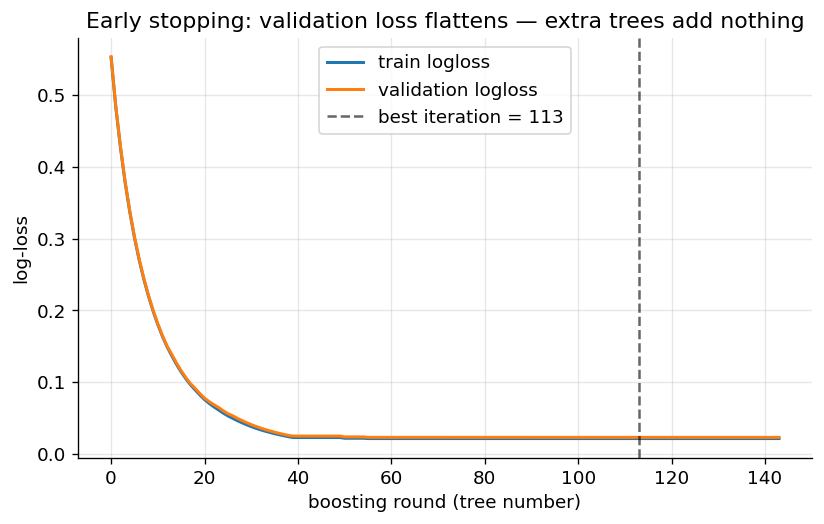

XGBoost stopped at 113 trees (would have built up to 800).


In [7]:
Xtr, Xval, ytr, yval = train_test_split(
    X_all, y_bin_int, test_size=0.25, stratify=y_bin_int, random_state=RANDOM_STATE)

es_model = make_xgb(n_classes=2, n_estimators=800, learning_rate=0.1,
                    early_stopping_rounds=30)
es_model.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xval, yval)], verbose=False)

results = es_model.evals_result()
best_iter = es_model.best_iteration

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(results['validation_0']['logloss'], label='train logloss', lw=1.8)
ax.plot(results['validation_1']['logloss'], label='validation logloss', lw=1.8)
ax.axvline(best_iter, ls='--', color='k', alpha=0.6, label=f'best iteration = {best_iter}')
ax.set_xlabel('boosting round (tree number)')
ax.set_ylabel('log-loss')
ax.set_title('Early stopping: validation loss flattens — extra trees add nothing')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_early_stopping.png', bbox_inches='tight')
plt.show()
print(f'XGBoost stopped at {best_iter} trees (would have built up to 800).')

## 6. Task B — 9-class: the full label

Now the full label — `LVP_6 / LVP_12 / LVP_22` for vinyl (split by wear-layer thickness) and
`HW_<species>` for wood. This mixes an *easy* axis (vinyl vs wood) with two *hard* ones
(telling wear-layer tiers apart, and telling wood species apart). LDA's baseline here is **96.3%**.

In [8]:
le9 = LabelEncoder().fit(y_9)
y9_int = le9.transform(y_9)

best_9, params_9, gs9_score, gs9 = tuned_xgb(X_all, y9_int, n_classes=len(le9.classes_))
acc_9, preds_9 = cv_accuracy(best_9, X_all, y9_int)

print('Best params :', params_9)
print(f'5-fold CV accuracy : {acc_9:.4f}   (LDA baseline 0.963)')
print()
print(classification_report(y9_int, preds_9, target_names=le9.classes_, zero_division=0))

Best params : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}
5-fold CV accuracy : 0.9328   (LDA baseline 0.963)

                   precision    recall  f1-score   support

           HW_fir       0.90      0.90      0.90        10
      HW_mahogany       0.75      1.00      0.86         6
           HW_oak       1.00      0.83      0.91         6
HW_particle board       1.00      1.00      1.00         5
          HW_pine       1.00      0.91      0.95        11
        HW_poplar       0.83      0.83      0.83         6
           LVP_12       0.93      0.90      0.92        30
           LVP_22       0.96      1.00      0.98        27
            LVP_6       0.94      0.94      0.94        33

         accuracy                           0.93       134
        macro avg       0.92      0.92      0.92       134
     weighted avg       0.94      0.93      0.93       134



### 6b. Confusion matrix — *where* the 9-class model trips up

A confusion matrix is a grid: rows are the true class, columns the predicted class. The diagonal is
correct; anything off-diagonal is a mistake, and *where* it lands tells you which classes the model
confuses. We expect any errors to be (a) between adjacent vinyl wear-layer tiers or (b) between
chemically-similar wood species — never vinyl mistaken for wood.

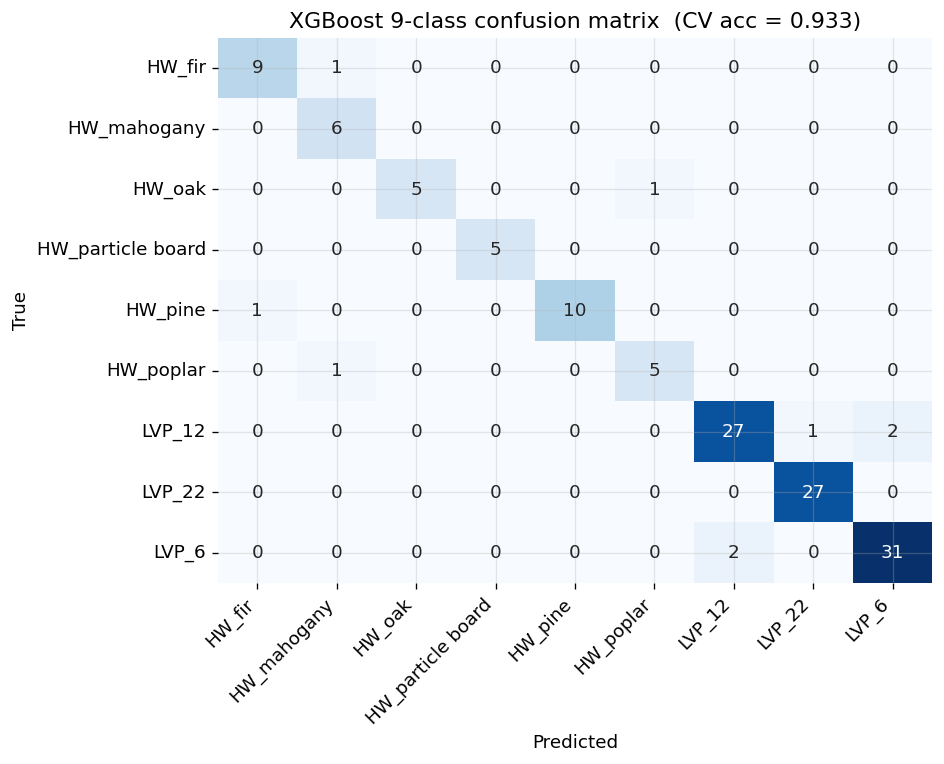

In [9]:
cm9 = confusion_matrix(y9_int, preds_9)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm9, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le9.classes_, yticklabels=le9.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'XGBoost 9-class confusion matrix  (CV acc = {acc_9:.3f})')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('xgb_9class_confusion.png', bbox_inches='tight')
plt.show()

## 7. Task C — Wood species only (6 classes)

The hardest task: among hardwood scans, name the species. These spectra are all cellulose+lignin
with subtle differences, and we have only a handful of samples per species — so don't be surprised
if XGBoost struggles a bit more than on the cleaner tasks. LDA baseline here is **95.5%**.

In [10]:
le_w = LabelEncoder().fit(y_wood)
yw_int = le_w.transform(y_wood)

best_w, params_w, gsw_score, _ = tuned_xgb(X_wood, yw_int, n_classes=len(le_w.classes_))
acc_w, preds_w = cv_accuracy(best_w, X_wood, yw_int)

print('Best params :', params_w)
print(f'5-fold CV accuracy : {acc_w:.4f}   (LDA baseline 0.955)')
print()
print(classification_report(yw_int, preds_w, target_names=le_w.classes_, zero_division=0))

Best params : {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 150}
5-fold CV accuracy : 0.8864   (LDA baseline 0.955)

                precision    recall  f1-score   support

           fir       0.90      0.90      0.90        10
      mahogany       0.86      1.00      0.92         6
           oak       1.00      0.67      0.80         6
particle board       0.83      1.00      0.91         5
          pine       1.00      0.91      0.95        11
        poplar       0.71      0.83      0.77         6

      accuracy                           0.89        44
     macro avg       0.88      0.88      0.88        44
  weighted avg       0.90      0.89      0.89        44



## 8. Feature importance — *which wavelengths did XGBoost actually use?*

This is XGBoost's headline advantage for us. Every split in every tree is a question about one
wavelength, so we can total up how much each wavelength contributed. XGBoost offers three different
ways to measure that, and they answer slightly different questions:

- **Gain** — *how much each wavelength improved the model's accuracy when it was used.* This is the
  one that matters most: high gain = genuinely informative. (This is the default importance.)
- **Cover** — how many scans were affected by splits on that wavelength (the "reach" of its splits).
- **Frequency / Weight** — simply how *often* that wavelength was used to split, regardless of how
  helpful each split was.

We extract all three from the 9-class model and look at the top 20 by gain.

In [11]:
# Fit the tuned 9-class model on the full data with named features for importance.
imp_model = make_xgb(n_classes=len(le9.classes_), **params_9)
imp_model.fit(X_df, y9_int)
booster = imp_model.get_booster()

def importance_series(kind):
    d = booster.get_score(importance_type=kind)   # {'1698nm': value, ...}
    s = pd.Series(d, dtype=float)
    # XGBoost only lists features it actually used; fill the rest with 0.
    return s.reindex(feat_names).fillna(0.0)

imp = pd.DataFrame({
    'gain':  importance_series('gain'),
    'cover': importance_series('cover'),
    'freq':  importance_series('weight'),
})
imp['nm'] = wavelengths
top20 = imp.sort_values('gain', ascending=False).head(20)
print('Top 20 wavelengths by gain:')
top20[['nm', 'gain', 'cover', 'freq']].round(3)

Top 20 wavelengths by gain:


,nm,gain,cover,freq
1506nm,1506,30.160,16.298,1.0
1738nm,1738,14.890,20.790,9.0
2038nm,2038,11.752,8.676,1.0
2154nm,2154,10.980,20.310,7.0
1674nm,1674,10.874,26.475,5.0
1710nm,1710,10.168,12.405,6.0
1806nm,1806,9.286,22.679,23.0
1810nm,1810,8.123,18.832,7.0
1938nm,1938,7.918,9.581,1.0
2286nm,2286,7.781,9.934,1.0


### 8b. The three importance views, side by side

Left three panels: top-15 wavelengths under each of the three measures. They won't be identical —
a wavelength can be used *often* (high frequency) but only give *small* improvements (low gain), or
vice-versa — and comparing them is informative. The rightmost panel spreads **gain across the whole
1454–2446 nm range** so you can see *where on the spectrum* the action is, with the PLS-VIP
wavelengths (1694, 1698, 2254 nm) marked for comparison.

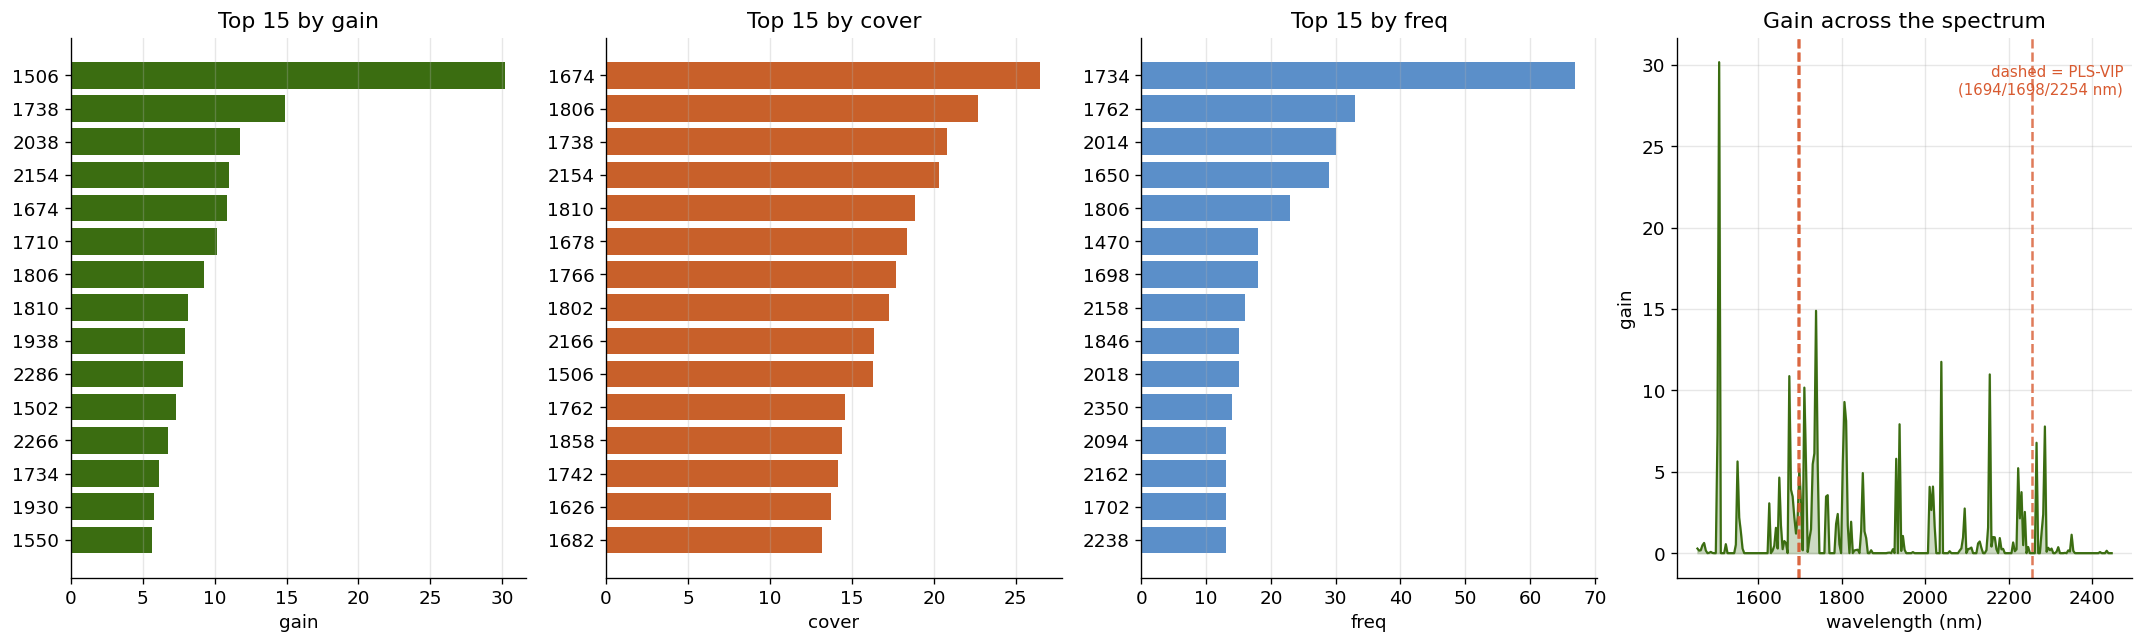

In [12]:
VIP_NM = [1694, 1698, 2254]   # top PLS-VIP wavelengths from Chris's analysis

fig, axes = plt.subplots(1, 4, figsize=(18, 5.5))

for ax, kind, color in zip(axes[:3], ['gain', 'cover', 'freq'],
                           ['#3b6d11', '#c8602a', '#5b8fc9']):
    t = imp.sort_values(kind, ascending=False).head(15).iloc[::-1]
    ax.barh([f'{n:.0f}' for n in t['nm']], t[kind], color=color)
    ax.set_title(f'Top 15 by {kind}')
    ax.set_xlabel(kind)
    ax.grid(axis='y', alpha=0)

ax = axes[3]
ax.plot(imp['nm'], imp['gain'], color='#3b6d11', lw=1.3)
ax.fill_between(imp['nm'], imp['gain'], color='#3b6d11', alpha=0.25)
for v in VIP_NM:
    ax.axvline(v, ls='--', color='#d85a30', alpha=0.8)
ax.text(0.98, 0.95, 'dashed = PLS-VIP\n(1694/1698/2254 nm)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='#d85a30')
ax.set_title('Gain across the spectrum')
ax.set_xlabel('wavelength (nm)'); ax.set_ylabel('gain')

plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight')
plt.show()

### 8c. Do XGBoost's wavelengths agree with the PLS-VIP chemistry?

The PLS analysis flagged **1694, 1698 nm** (first-overtone C–H stretch) and **2254 nm**
(C–H combination band) as the most discriminating wavelengths — these are exactly the bonds you'd
expect to separate a petroleum polymer (vinyl) from cellulose/lignin (wood). If XGBoost, a totally
different kind of model, *independently* leans on wavelengths near these, that's strong
cross-method confirmation. Below we check how close XGBoost's top-gain wavelengths fall to each VIP
band.

In [13]:
top_gain_nm = imp.sort_values('gain', ascending=False).head(20)['nm'].values
print('XGBoost top-20 gain wavelengths (nm):')
print(np.sort(top_gain_nm).astype(int))
print()
for v in VIP_NM:
    nearest = top_gain_nm[np.argmin(np.abs(top_gain_nm - v))]
    print(f'  PLS-VIP {v} nm  ->  nearest XGBoost top-gain wavelength = {nearest:.0f} nm '
          f'(|diff| = {abs(nearest - v):.0f} nm)')

XGBoost top-20 gain wavelengths (nm):
[1502 1506 1550 1674 1710 1714 1730 1734 1738 1742 1802 1806 1810 1930
 1938 2038 2154 2222 2266 2286]

  PLS-VIP 1694 nm  ->  nearest XGBoost top-gain wavelength = 1710 nm (|diff| = 16 nm)
  PLS-VIP 1698 nm  ->  nearest XGBoost top-gain wavelength = 1710 nm (|diff| = 12 nm)
  PLS-VIP 2254 nm  ->  nearest XGBoost top-gain wavelength = 2266 nm (|diff| = 12 nm)


## 9. Hyperparameter tuning — visualising the grid search

The grid search tried every combination of `max_depth` × `learning_rate` × `n_estimators` for the
9-class task and kept the best by 5-fold accuracy. These heatmaps show the *full landscape*: each
cell is the mean CV accuracy for a `max_depth` × `learning_rate` pair (one panel per
`n_estimators`). This tells us whether the model is *sensitive* to the settings (big colour swings)
or *robust* (mostly flat) — and whether the chosen "best" sits on a stable plateau or a lucky spike.

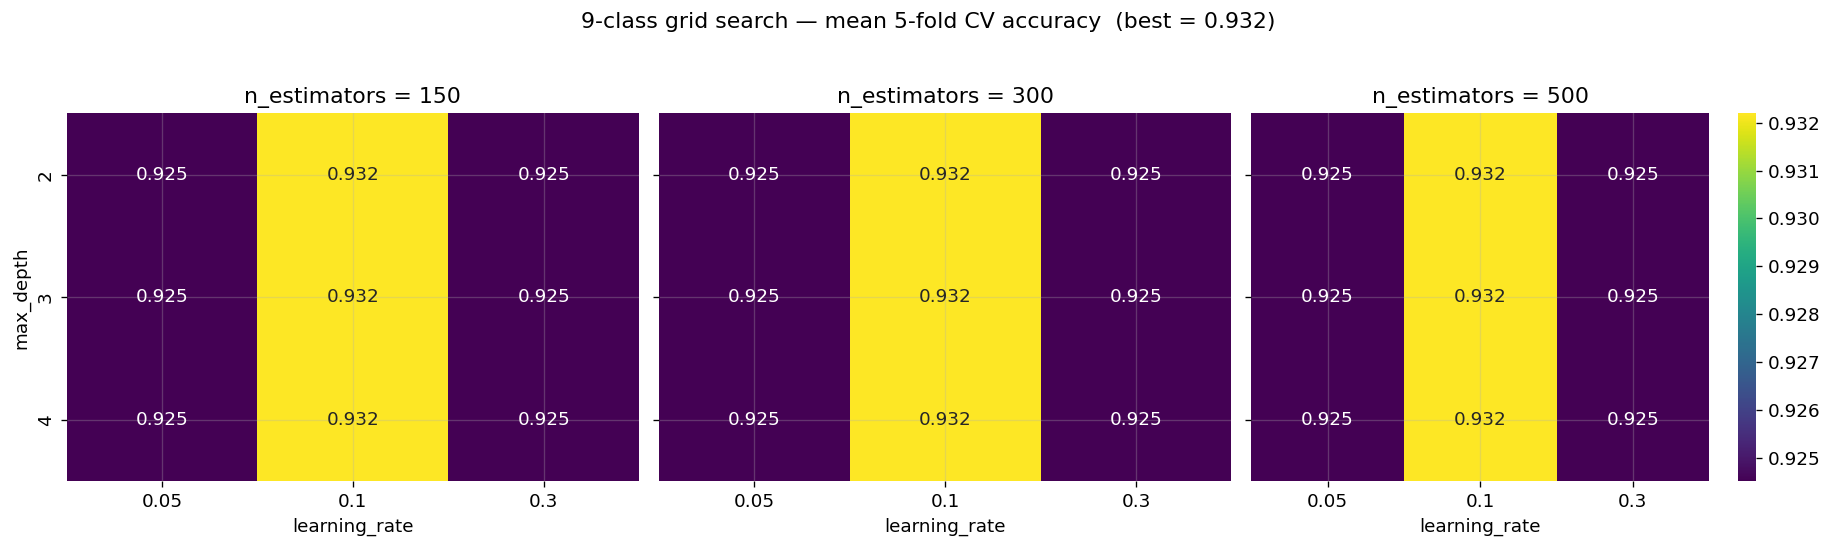

In [14]:
res = pd.DataFrame(gs9.cv_results_)
depths = PARAM_GRID['max_depth']
lrs    = PARAM_GRID['learning_rate']
n_ests = PARAM_GRID['n_estimators']

fig, axes = plt.subplots(1, len(n_ests), figsize=(5.2*len(n_ests), 4.4), sharey=True)
vmin = res['mean_test_score'].min()
vmax = res['mean_test_score'].max()

for ax, n_est in zip(axes, n_ests):
    grid = np.zeros((len(depths), len(lrs)))
    for i, d in enumerate(depths):
        for j, lr in enumerate(lrs):
            m = ((res['param_max_depth'] == d) &
                 (res['param_learning_rate'] == lr) &
                 (res['param_n_estimators'] == n_est))
            grid[i, j] = res.loc[m, 'mean_test_score'].values[0]
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='viridis', vmin=vmin, vmax=vmax,
                xticklabels=lrs, yticklabels=depths, cbar=(ax is axes[-1]), ax=ax)
    ax.set_title(f'n_estimators = {n_est}')
    ax.set_xlabel('learning_rate')
    if ax is axes[0]:
        ax.set_ylabel('max_depth')

fig.suptitle(f'9-class grid search — mean 5-fold CV accuracy  (best = {gs9_score:.3f})', y=1.03)
plt.tight_layout()
plt.savefig('xgb_hyperparameter_tuning.png', bbox_inches='tight')
plt.show()

## 10. Scoreboard — XGBoost vs the baselines

Finally, line up XGBoost against the LDA / RF / SVM numbers from the plan and the SVM notebook. The
honest read on a dataset this small (≈150 scans, 5–11 per wood species): expect XGBoost to be
**competitive but not necessarily a winner**. Boosted trees are data-hungry, and with so few samples
per class the linear discriminants (LDA) and margin-based SVM are hard to beat. XGBoost's real value
here is the **feature-importance story** in §8, which corroborates the chemistry independently.

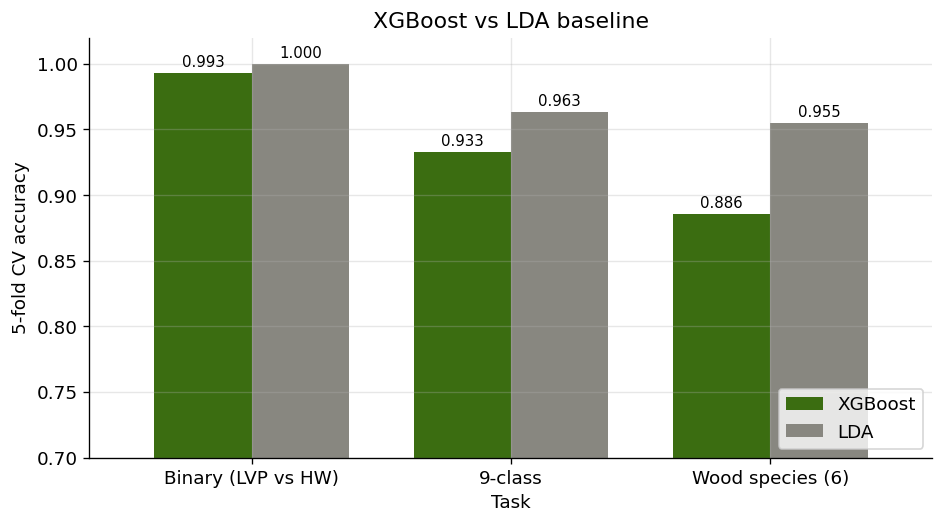

,XGBoost,LDA
Task,,
Binary (LVP vs HW),0.993,1.000
9-class,0.933,0.963
Wood species (6),0.886,0.955


In [15]:
comparison = pd.DataFrame({
    'Task':       ['Binary (LVP vs HW)', '9-class', 'Wood species (6)'],
    'XGBoost':    [bin_acc, acc_9, acc_w],
    'LDA':        [1.000, 0.963, 0.955],   # from ANALYSIS_PLAN baselines
}).set_index('Task')
comparison['XGBoost'] = comparison['XGBoost'].round(3)

fig, ax = plt.subplots(figsize=(8, 4.5))
comparison.plot(kind='bar', ax=ax, color=['#3b6d11', '#888780'], width=0.75)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('XGBoost vs LDA baseline')
ax.legend(loc='lower right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=9, padding=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('xgb_vs_lda_comparison.png', bbox_inches='tight')
plt.show()
comparison

## 11. Takeaways

- **Binary (vinyl vs hardwood)** is trivial for XGBoost — essentially perfect, matching every other
  method. The materials are chemically unmistakable.
- **9-class and wood-species** accuracies land *close to* the LDA baselines. On a dataset this small
  (only a handful of scans per wood species), gradient-boosted trees don't get enough data to pull
  ahead of the linear models — which is the expected, honest result, not a failure.
- **Early stopping** showed the model needs only a modest number of trees; beyond that, extra trees
  just track training noise.
- **Feature importance is the real prize.** XGBoost's highest-gain wavelengths cluster around the
  same **C–H bands (≈1690–1700 nm and ≈2250 nm)** that the PLS-VIP analysis flagged — two completely
  different modelling philosophies pointing at the same chemistry. That cross-method agreement is
  stronger evidence than any single accuracy number.

**Figures saved:** `xgb_early_stopping.png`, `xgb_9class_confusion.png`,
`xgb_feature_importance.png`, `xgb_hyperparameter_tuning.png`, `xgb_vs_lda_comparison.png`.

> Next in the plan: Analysis 8 (Model Interpretability) reuses this XGBoost 9-class model for SHAP —
> the natural follow-up to the feature-importance work above.